# LSTM Data Preparation and Training

Builds sliding-window sequences from `data/processed/features.csv` (proposal.txt Sections 10.6-11) and trains a single-layer LSTM to predict the next hour's demand from the previous `sequence_length` hours of demand, weather, and calendar variables. The hand-crafted lag/rolling columns from `05_feature_engineering.ipynb` and the economic passthrough columns (`gdp`, `electricity_price`, `per_capita_energy_use`) are excluded here -- the recurrent architecture learns temporal dependencies directly from the raw sequence, and the economic columns are kept out of the model features for now, consistent with `08_ml_models.ipynb`.

In [3]:
import sys
from pathlib import Path

import yaml

# Works both in the local repo and on Kaggle. Locally, config.yaml is read
# from disk. On Kaggle there is no repo checkout -- only whatever cells you
# paste -- so the config is built inline instead, pointed at the attached
# dataset under /kaggle/input.
IS_KAGGLE = Path("/kaggle/input/datasets/uom230425m/time-series-project").exists()

if IS_KAGGLE:
    import os

    available = os.listdir("/kaggle/input/datasets/uom230425m/time-series-project")
    print("Kaggle input datasets found:", available)
    if len(available) != 1:
        raise RuntimeError(
            "Expected exactly one dataset under /kaggle/input -- set "
            "KAGGLE_DATASET_DIR manually to the one containing "
            "load_forecasting_dataset_corrected.csv."
        )
    KAGGLE_DATASET_DIR = Path("/kaggle/input/datasets/uom230425m/time-series-project") / available[0]

    REPO_ROOT = Path("/kaggle/working")
    config = {
        "data": {
            "raw_path": str(KAGGLE_DATASET_DIR),
            "processed_path": "/kaggle/working/data/processed",
            "processed_file": "/kaggle/working/data/processed/demand_clean.csv",
            "features_file": "/kaggle/working/data/processed/features.csv",
            "timestamp_col": "timestamp",
            "target_col": "demand",
            "frequency": "h",
        },
        "split": {"train_ratio": 0.70, "val_ratio": 0.15, "test_ratio": 0.15},
        "lstm": {
            "sequence_length": 24,
            "units": 64,
            "layers": 1,
            "dropout": 0.2,
            "batch_size": 32,
            "learning_rate": 0.001,
            "epochs": 50,
            "early_stopping_patience": 5,
        },
        "models": {
            "lstm_path": "/kaggle/working/models/lstm_model.h5",
            "lstm_scaler_path": "/kaggle/working/models/lstm_scaler.pkl",
            "lstm_feature_columns": "/kaggle/working/models/lstm_feature_columns.json",
        },
    }
else:
    def find_repo_root(start: Path) -> Path:
        for parent in [start, *start.parents]:
            if (parent / "config.yaml").exists():
                return parent
        raise FileNotFoundError("config.yaml not found in any parent directory")

    REPO_ROOT = find_repo_root(Path.cwd())
    sys.path.insert(0, str(REPO_ROOT))

    with open(REPO_ROOT / "config.yaml") as f:
        config = yaml.safe_load(f)

config

Kaggle input datasets found: ['load_forecasting_dataset_corrected.csv']


{'data': {'raw_path': '/kaggle/input/datasets/uom230425m/time-series-project/load_forecasting_dataset_corrected.csv',
  'processed_path': '/kaggle/working/data/processed',
  'processed_file': '/kaggle/working/data/processed/demand_clean.csv',
  'features_file': '/kaggle/working/data/processed/features.csv',
  'timestamp_col': 'timestamp',
  'target_col': 'demand',
  'frequency': 'h'},
 'split': {'train_ratio': 0.7, 'val_ratio': 0.15, 'test_ratio': 0.15},
 'lstm': {'sequence_length': 24,
  'units': 64,
  'layers': 1,
  'dropout': 0.2,
  'batch_size': 32,
  'learning_rate': 0.001,
  'epochs': 50,
  'early_stopping_patience': 5},
 'models': {'lstm_path': '/kaggle/working/models/lstm_model.h5',
  'lstm_scaler_path': '/kaggle/working/models/lstm_scaler.pkl',
  'lstm_feature_columns': '/kaggle/working/models/lstm_feature_columns.json'}}

In [4]:
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping

# On Kaggle, src/ isn't on disk (only pasted cells are) -- these are
# identical inline copies of src/data/load_data.py, src/models/deep_learning.py,
# src/evaluation/metrics.py, and src/visualization/plots.py.
# Keep them in sync with src/ if that logic ever changes.
if IS_KAGGLE:
    from tensorflow import keras
    from tensorflow.keras import layers

    def load_raw_data(path, timestamp_col="timestamp"):
        df = pd.read_csv(path, parse_dates=[timestamp_col])
        return df.sort_values(timestamp_col).reset_index(drop=True)

    def set_timestamp_index(df, timestamp_col="timestamp"):
        df = df.set_index(timestamp_col)
        return df.sort_index()

    def chronological_split(df, train_ratio, val_ratio):
        n = len(df)
        train_end = int(n * train_ratio)
        val_end = int(n * (train_ratio + val_ratio))
        return df.iloc[:train_end], df.iloc[train_end:val_end], df.iloc[val_end:]

    def create_sequences(data, target_idx, sequence_length):
        X, y = [], []
        for i in range(sequence_length, len(data)):
            X.append(data[i - sequence_length:i])
            y.append(data[i, target_idx])
        return np.array(X), np.array(y)

    def build_lstm_model(sequence_length, n_features, units=64, dropout=0.2, learning_rate=0.001):
        model = keras.Sequential([
            layers.Input(shape=(sequence_length, n_features)),
            layers.LSTM(units),
            layers.Dropout(dropout),
            layers.Dense(1),
        ])
        model.compile(optimizer=keras.optimizers.Adam(learning_rate), loss="mse")
        return model

    def mae(y_true, y_pred):
        return np.mean(np.abs(y_true - y_pred))

    def rmse(y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred) ** 2))

    def mape(y_true, y_pred):
        return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    def smape(y_true, y_pred):
        denom = (np.abs(y_true) + np.abs(y_pred)) / 2
        return np.mean(np.abs(y_true - y_pred) / denom) * 100

    def mase(y_true, y_pred, y_train, season_length=1):
        naive_error = np.mean(np.abs(y_train[season_length:] - y_train[:-season_length]))
        return np.mean(np.abs(y_true - y_pred)) / naive_error

    def plot_training_history(history, title="Training and Validation Loss"):
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(history.history["loss"], label="Training loss")
        ax.plot(history.history["val_loss"], label="Validation loss")
        ax.set_title(title)
        ax.legend()
        return fig

    def plot_actual_vs_predicted(y_true, y_pred, title="Actual vs Predicted"):
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(y_true.index, y_true.values, label="Actual")
        ax.plot(y_pred.index, y_pred.values, label="Predicted", alpha=0.8)
        ax.set_title(title)
        ax.legend()
        return fig
else:
    from src.data.load_data import chronological_split, load_raw_data, set_timestamp_index
    from src.evaluation.metrics import mae, mape, mase, rmse, smape
    from src.models.deep_learning import build_lstm_model, create_sequences
    from src.visualization.plots import plot_actual_vs_predicted, plot_training_history

FEATURES_PATH = REPO_ROOT / config["data"]["features_file"]
TIMESTAMP_COL = config["data"]["timestamp_col"]
TARGET_COL = config["data"]["target_col"]
TRAIN_RATIO = config["split"]["train_ratio"]
VAL_RATIO = config["split"]["val_ratio"]
SEQ_LEN = config["lstm"]["sequence_length"]

## Load features and select LSTM input columns

In [5]:
df = load_raw_data(FEATURES_PATH, TIMESTAMP_COL)
df = set_timestamp_index(df, TIMESTAMP_COL)

FEATURE_COLS = [
    TARGET_COL, "temperature", "humidity", "wind_speed", "rainfall", "solar_irradiance",
    "public_event", "is_weekend", "hour_sin", "hour_cos",
    "day_of_week_sin", "day_of_week_cos", "month_sin", "month_cos",
]
TARGET_IDX = FEATURE_COLS.index(TARGET_COL)

df = df[FEATURE_COLS]
train_df, val_df, test_df = chronological_split(df, TRAIN_RATIO, VAL_RATIO)
print(f"Train: {len(train_df)} rows, Val: {len(val_df)} rows, Test: {len(test_df)} rows")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Train: 33112 rows, Val: 7096 rows, Test: 7096 rows
Features (14): ['demand', 'temperature', 'humidity', 'wind_speed', 'rainfall', 'solar_irradiance', 'public_event', 'is_weekend', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos']


## Scale features

Fitted only on the training split (proposal.txt Section 11.1) to avoid leaking validation/test statistics into the transform.

In [6]:
scaler = MinMaxScaler()
scaler.fit(train_df)

train_scaled = scaler.transform(train_df)
# Prepend each split's SEQ_LEN warm-up rows from the *previous* split so no
# val/test observations are lost to sequence construction, without using
# any information from the future.
val_scaled = scaler.transform(pd.concat([train_df.tail(SEQ_LEN), val_df]))
test_scaled = scaler.transform(pd.concat([val_df.tail(SEQ_LEN), test_df]))

## Build sequences

In [7]:
X_train, y_train = create_sequences(train_scaled, TARGET_IDX, SEQ_LEN)
X_val, y_val = create_sequences(val_scaled, TARGET_IDX, SEQ_LEN)
X_test, y_test = create_sequences(test_scaled, TARGET_IDX, SEQ_LEN)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X_train: (33088, 24, 14), X_val: (7096, 24, 14), X_test: (7096, 24, 14)


## Build and train the LSTM

In [8]:
model = build_lstm_model(
    sequence_length=SEQ_LEN,
    n_features=len(FEATURE_COLS),
    units=config["lstm"]["units"],
    dropout=config["lstm"]["dropout"],
    learning_rate=config["lstm"]["learning_rate"],
)
model.summary()

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=config["lstm"]["early_stopping_patience"],
    restore_best_weights=True,
)

start = time.perf_counter()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=config["lstm"]["batch_size"],
    epochs=config["lstm"]["epochs"],
    callbacks=[early_stopping],
    verbose=2,
)
training_time = time.perf_counter() - start
print(f"Trained in {training_time:.1f}s over {len(history.history['loss'])} epochs")

I0000 00:00:1785931832.145780     311 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13654 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785931832.148882     311 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1034/1034 - 8s - 8ms/step - loss: 0.0180 - val_loss: 0.0153
Epoch 2/50
1034/1034 - 5s - 5ms/step - loss: 0.0163 - val_loss: 0.0153
Epoch 3/50
1034/1034 - 5s - 5ms/step - loss: 0.0160 - val_loss: 0.0153
Epoch 4/50
1034/1034 - 5s - 5ms/step - loss: 0.0158 - val_loss: 0.0156
Epoch 5/50
1034/1034 - 5s - 5ms/step - loss: 0.0156 - val_loss: 0.0152
Epoch 6/50
1034/1034 - 5s - 5ms/step - loss: 0.0156 - val_loss: 0.0153
Epoch 7/50
1034/1034 - 5s - 5ms/step - loss: 0.0155 - val_loss: 0.0153
Epoch 8/50
1034/1034 - 5s - 5ms/step - loss: 0.0154 - val_loss: 0.0153
Epoch 9/50
1034/1034 - 5s - 5ms/step - loss: 0.0154 - val_loss: 0.0152
Epoch 10/50
1034/1034 - 5s - 5ms/step - loss: 0.0154 - val_loss: 0.0152
Epoch 11/50
1034/1034 - 5s - 5ms/step - loss: 0.0153 - val_loss: 0.0153
Epoch 12/50
1034/1034 - 5s - 5ms/step - loss: 0.0153 - val_loss: 0.0152
Epoch 13/50
1034/1034 - 5s - 5ms/step - loss: 0.0153 - val_loss: 0.0152
Epoch 14/50
1034/1034 - 5s - 5ms/step - loss: 0.0153 - val_loss: 0.0152
E

## Training/validation loss curve

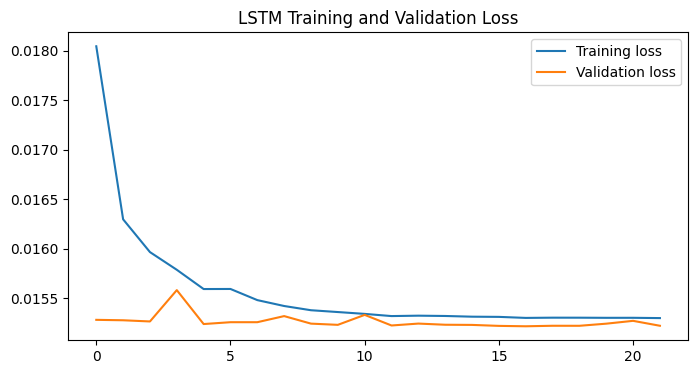

In [9]:
FIGURES_DIR = REPO_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig = plot_training_history(history, title="LSTM Training and Validation Loss")
fig.savefig(FIGURES_DIR / "lstm_training_history.png", dpi=150, bbox_inches="tight")

## Predict on the test set and inverse-transform

The scaler was fit on all `FEATURE_COLS` jointly, so predictions are placed back into a full-width array (zeros for the other columns) before calling `inverse_transform`, then the target column is sliced back out (proposal.txt Section 11.5).

In [10]:
def inverse_transform_target(scaled_target, scaler, target_idx, n_features):
    padded = np.zeros((len(scaled_target), n_features))
    padded[:, target_idx] = scaled_target
    return scaler.inverse_transform(padded)[:, target_idx]

start = time.perf_counter()
y_pred_scaled = model.predict(X_test, verbose=0).ravel()
prediction_time = time.perf_counter() - start

y_pred_arr = inverse_transform_target(y_pred_scaled, scaler, TARGET_IDX, len(FEATURE_COLS))
y_true_arr = inverse_transform_target(y_test, scaler, TARGET_IDX, len(FEATURE_COLS))

test_index = test_df.index  # aligned 1:1 with X_test/y_test thanks to the warm-up prepend
y_true = pd.Series(y_true_arr, index=test_index, name=TARGET_COL)
y_pred = pd.Series(y_pred_arr, index=test_index, name=TARGET_COL)

## Evaluate on the test set

In [11]:
y_train_original = inverse_transform_target(y_train, scaler, TARGET_IDX, len(FEATURE_COLS))

results_df = pd.DataFrame([{
    "model": "LSTM",
    "mae": mae(y_true, y_pred),
    "rmse": rmse(y_true, y_pred),
    "mape": mape(y_true, y_pred),
    "smape": smape(y_true, y_pred),
    "mase": mase(y_true.to_numpy(), y_pred.to_numpy(), y_train_original, season_length=24),
    "training_time_seconds": training_time,
    "prediction_time_seconds": prediction_time,
}])
results_df

,model,mae,rmse,mape,smape,mase,training_time_seconds,prediction_time_seconds
0,LSTM,79.936125,100.45777,5.384521,5.342819,0.704926,109.745839,0.763209


## Visualize the forecast

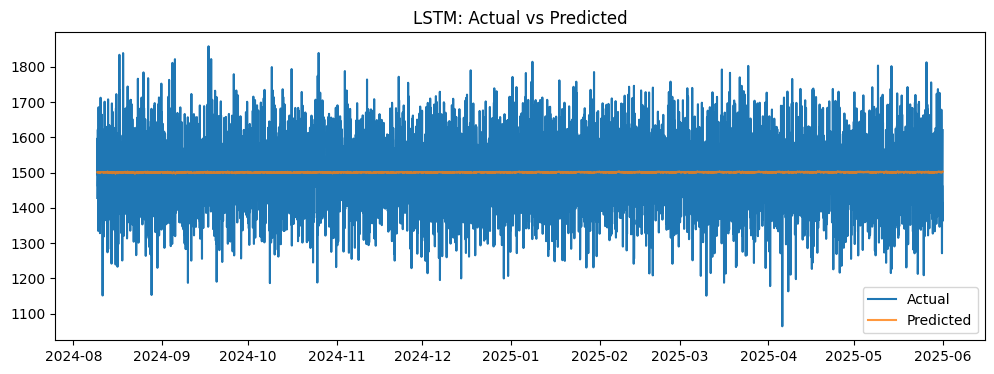

In [12]:
fig = plot_actual_vs_predicted(y_true, y_pred, title="LSTM: Actual vs Predicted")
fig.savefig(FIGURES_DIR / "lstm_forecast.png", dpi=150, bbox_inches="tight")

## Save predictions and results

In [13]:
predictions_df = pd.DataFrame({
    "timestamp": test_index,
    "actual": y_true.values,
    "predicted": y_pred.values,
    "model": "LSTM",
})

PREDICTIONS_PATH = REPO_ROOT / "reports" / "dl_predictions.csv"
predictions_df.to_csv(PREDICTIONS_PATH, index=False)

RESULTS_PATH = REPO_ROOT / "reports" / "dl_metrics.csv"
results_df.to_csv(RESULTS_PATH, index=False)

print(f"Saved {len(predictions_df)} prediction rows to {PREDICTIONS_PATH}")
print(f"Saved DL results to {RESULTS_PATH}")

Saved 7096 prediction rows to /kaggle/working/reports/dl_predictions.csv
Saved DL results to /kaggle/working/reports/dl_metrics.csv


## Save the model artifact

In [14]:
MODELS_DIR = REPO_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model.save(REPO_ROOT / config["models"]["lstm_path"])
joblib.dump(scaler, REPO_ROOT / config["models"]["lstm_scaler_path"])
with open(REPO_ROOT / config["models"]["lstm_feature_columns"], "w") as f:
    json.dump(FEATURE_COLS, f, indent=1)

print(f"Saved LSTM model, scaler, and {len(FEATURE_COLS)} feature columns to {MODELS_DIR}")

Saved LSTM model, scaler, and 14 feature columns to /kaggle/working/models
